In [24]:
### Import necessary libraries for modeling ###
import pandas as pd
import numpy as np
import torch
import random
import json
import matplotlib.pyplot as plt
from itables import show

from scipy.stats import kendalltau
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

In [16]:
# Set random seed for reproducibility
TARGET_VARIABLE = "Mole fraction"
torch.manual_seed(101)
np.random.seed(101)
random.seed(101)

In [17]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
X_val = pd.read_csv("X_val.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")
y_val = pd.read_csv("y_val.csv")

In [18]:
X_train.drop(
    columns=["Component 1", "Component 2", "Smiles 1", "Smiles 2", "mol1", "mol2"],
    inplace=True
)
X_test.drop(
    columns=["Component 1", "Component 2", "Smiles 1", "Smiles 2", "mol1", "mol2"],
    inplace=True
)
X_val.drop(
    columns=["Component 1", "Component 2", "Smiles 1", "Smiles 2", "mol1", "mol2"],
    inplace=True
)

In [19]:
def separate_features(X):
    return X.iloc[:, 0:3], X.iloc[:, 3:203], X.iloc[:, 203:403],  X.iloc[:, 403:428], X.iloc[:, 428:]
# property_T_P, Component 1 Descriptors, Component 2 Descriptors, Property category, phase

In [20]:
X_train_prop, X_train_comp1_desc, X_train_comp2_desc, X_train_prop_cat, X_train_phase = separate_features(X_train)
X_test_prop, X_test_comp1_desc, X_test_comp2_desc, X_test_prop_cat, X_test_phase = separate_features(X_test)
X_val_prop, X_val_comp1_desc, X_val_comp2_desc, X_val_prop_cat, X_val_phase = separate_features(X_val)

In [21]:
def make_symmetric(comp1, comp2):
    X1 = np.array(comp1)
    X2 = np.array(comp2)
    prod = pd.DataFrame(X1 * X2, columns=[f'prod_{i}' for i in range(X1.shape[1])])
    summ = pd.DataFrame(X1 + X2, columns=[f'sum_{i}'  for i in range(X1.shape[1])])
    return pd.concat([prod, summ], axis=1)

X_train_symmetric = make_symmetric(X_train_comp1_desc, X_train_comp2_desc)
X_val_symmetric   = make_symmetric(X_val_comp1_desc,   X_val_comp2_desc)
X_test_symmetric  = make_symmetric(X_test_comp1_desc,  X_test_comp2_desc)

# Reconstruct full feature matrix
def reconstruct(prop, symmetric, prop_cat, phase):
    dfs = [prop, symmetric, prop_cat, phase]
    for df in dfs:
        df.reset_index(drop=True, inplace=True)
    return pd.concat(dfs, axis=1)

X_train = reconstruct(X_train_prop, X_train_symmetric, X_train_prop_cat, X_train_phase)
X_val   = reconstruct(X_val_prop,   X_val_symmetric,   X_val_prop_cat,   X_val_phase)
X_test  = reconstruct(X_test_prop,  X_test_symmetric,  X_test_prop_cat,  X_test_phase)

In [26]:
def evaluate_model(model,
                   X_test: pd.DataFrame,
                   y_test,
                   show_plot: bool=False,
                   save_file: bool=False,
                   save_path: str="./Linear/Linear_test_results.json") -> None | str:
    """Evaluate the model's performance on the test set and optionally save the results."""
    # check if model is provided
    assert model is not None, "Model must be provided for evaluation."

    y_pred = model.predict(X_test)
    y_test = np.array(y_test).flatten()
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    tau = kendalltau(y_test, y_pred).correlation

    # Bootstrap — only for CI
    rng = np.random.default_rng(101)
    mae_scores = []
    mse_scores = []
    r2_scores = []
    tau_scores = []
    for _ in range(1000):
        idx = rng.integers(0, len(y_test), len(y_test))
        mae_scores.append(mean_absolute_error(y_test[idx], y_pred[idx]))
        mse_scores.append(mean_squared_error(y_test[idx], y_pred[idx]))
        r2_scores.append(r2_score(y_test[idx], y_pred[idx]))
        tau_scores.append(kendalltau(y_test[idx], y_pred[idx]).correlation)

    mae_scores = np.array(mae_scores)
    mse_scores = np.array(mse_scores)
    r2_scores = np.array(r2_scores)
    tau_scores = np.array(tau_scores)

    mae_std = np.std(mae_scores)
    mse_std = np.std(mse_scores)
    r2_std  = np.std(r2_scores)
    tau_std = np.std(tau_scores)

    mae_ci  = np.percentile(mae_scores, [2.5, 97.5])
    mse_ci  = np.percentile(mse_scores, [2.5, 97.5])
    r2_ci   = np.percentile(r2_scores,  [2.5, 97.5])
    tau_ci  = np.percentile(tau_scores, [2.5, 97.5])

    print(f"MAE          = {mae:.4f}, Std: {mae_std:.4f} (95% CI: {mae_ci[0]:.4f}–{mae_ci[1]:.4f})")
    print(f"MSE          = {mse:.4f}, Std: {mse_std:.4f} (95% CI: {mse_ci[0]:.4f}–{mse_ci[1]:.4f})")
    print(f"R²           = {r2:.4f}, Std: {r2_std:.4f} (95% CI: {r2_ci[0]:.4f}–{r2_ci[1]:.4f})")
    print(f"Kendall's τ  = {tau:.4f}, Std: {tau_std:.4f} (95% CI: {tau_ci[0]:.4f}–{tau_ci[1]:.4f})")

    if save_file:
        results = {
            "Test MSE": mse,
            "Test MAE": mae,
            "Test R^2 Score": r2,
            "Kendall's Tau": tau,
        }
        with open(save_path, "w") as f:
            json.dump(results, f)
        print(f"Test results saved to {save_path}")

    if show_plot:
        plt.figure(figsize=(6, 6))
        plt.scatter(y_test, y_pred, alpha=0.1, s=10)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                 "r--", label="True Y")
        plt.legend()
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title("Actual vs Predicted")
        plt.show()

    return None

MAE          = 0.2503, Std: 0.0190 (95% CI: 0.2284–0.2900)
MSE          = 3.6641, Std: 3.6722 (95% CI: 0.0792–10.8205)
R²           = -37.5021, Std: 38.5850 (95% CI: -113.5257–0.1693)
Kendall's τ  = 0.2450, Std: 0.0062 (95% CI: 0.2321–0.2568)


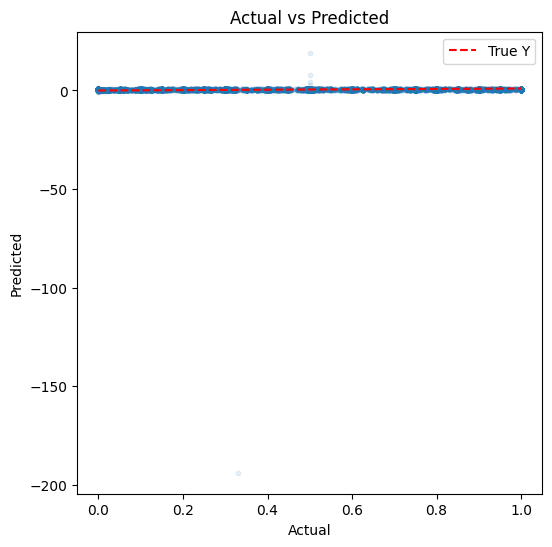

In [27]:
# Scale features (good practice even for linear regression)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)
evaluate_model(pipeline, X_test, y_test, show_plot=True)

In [25]:
joblib.dump(pipeline, 'linear_baseline.pkl')

['linear_baseline.pkl']